# CIA Landenanalyse en Clustering
Bron: Al deze datasets zijn samengesteld uit gegevens van de Amerikaanse overheid.
https://www.cia.gov/library/publications/the-world-factbook/docs/faqs.html

## Doel:
**Inzichten verkrijgen in de gelijkenis tussen landen en regio's van de wereld door te experimenteren met een verschillende aantal clusters.** <p>Zoek een interpretatie voor de clusters; maw wat vertegenwoordigen deze clusters? Let op: Er is geen 100% juist antwoord...</p>

----

## Importeren en Data
**OPDRACHT: Voer de volgende cellen uit om bibliotheken te importeren en gegevens in te lezen.**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('../data/CIA_Country_Facts.csv')

## Verkennende Data Analyse

**TAAK: Verken de rijen en kolommen van de gegevens, evenals de datatypes van de kolommen.**

In [3]:
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


Het is een kleine dataset inzake aantal rijen, maar het aantal landen is nu eenmaal beperkt...

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

## Uitleg van de features:

Population: Dit is het totale aantal mensen dat in een land of regio woont.

Area (sq. mi.): Dit is de totale oppervlakte van een land of regio uitgedrukt in vierkante mijlen.

Pop. Density (per sq. mi.): Dit is de bevolkingsdichtheid, die het gemiddelde aantal mensen per vierkante mijl aangeeft. Het geeft een idee van hoe dichtbevolkt een gebied is.

Coastline (coast/area ratio): Dit is de verhouding tussen de lengte van de kustlijn van een land en zijn totale oppervlakte, wat een indicatie geeft van hoe 'kustrijk' een land is.

Net migration: Dit is het nettoaantal mensen dat per jaar naar een land emigreert (immigratie) minus het aantal mensen dat emigreert (emigratie). Een positief getal duidt op een netto-immigratie, terwijl een negatief getal duidt op een netto-emigratie.

Infant mortality (per 1000 births): Dit is het aantal zuigelingen dat sterft voordat het de leeftijd van één jaar bereikt, per 1000 levendgeborenen in een bepaald jaar.

GDP ($ per capita): Dit is het Bruto Binnenlands Product per persoon, wat een maatstaf is voor de economische productie die toegerekend wordt aan elke inwoner van het land.

Literacy (%): Dit is het percentage van de volwassen bevolking (meestal mensen ouder dan 15 jaar) dat lees- en schrijfvaardig is.

Phones (per 1000): Dit geeft het gemiddeld aantal telefoonaansluitingen per 1000 inwoners aan. Het is een indicator van de telecommunicatie-infrastructuur en -toegankelijkheid binnen een regio of land.

Arable (%): Het percentage van het totale landoppervlak dat geschikt is voor landbouw. Dit is belangrijk om de agrarische capaciteit en het potentieel voor voedselproductie te beoordelen.

Crops (%): Het percentage van het totale land dat permanent wordt gebruikt voor de verbouwing van gewassen zoals tarwe, mais, of rijst.

Other (%): Het percentage van het land dat niet valt onder de categorieën 'arable' of 'crops'. Dit kan land zijn dat wordt gebruikt voor andere doeleinden zoals wonen, industrie, bossen, enz.

Climate: Een categorische of numerieke waarde die het type klimaat van een regio aangeeft. Dit kan variëren van droog tot tropisch, en het heeft invloed op vele aspecten van het leven, waaronder landbouw, levensstijl, en de economie.

Birthrate: Het aantal geboorten per jaar per 1000 mensen in de bevolking. Het is een belangrijke demografische indicator die bijdraagt aan de groeisnelheid van de bevolking.

Deathrate: Het aantal sterfgevallen per jaar per 1000 mensen in de bevolking. Samen met de geboortecijfers kan dit helpen om de natuurlijke bevolkingsgroei of -afname te bepalen.

Agriculture: Het percentage van het bruto nationaal product (BNP) dat wordt bijgedragen door landbouw en boerderij-gerelateerde industrieën. Dit getal kan een indicator zijn van de mate waarin een land of regio afhankelijk is van de landbouw voor zijn economische productie.

Industry: Het percentage van het BNP dat wordt bijgedragen door de industriële sector, waaronder productie, mijnbouw, en constructie. Dit weerspiegelt het industriële ontwikkelingsniveau van een land.

Service: Het percentage van het BNP dat wordt bijgedragen door de dienstensector, inclusief gebieden zoals onderwijs.

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Population,227.0,2.874028e+07,1.178913e+08,7026.000,437624.00000,4786994.000,1.749777e+07,1.313974e+09
Area (sq. mi.),227.0,5.982270e+05,1.790282e+06,2.000,4647.50000,86600.000,4.418110e+05,1.707520e+07
Pop. Density (per sq. mi.),227.0,3.790471e+02,1.660186e+03,0.000,29.15000,78.800,1.901500e+02,1.627150e+04
Coastline (coast/area ratio),227.0,2.116533e+01,7.228686e+01,0.000,0.10000,0.730,1.034500e+01,8.706600e+02
Net migration,224.0,3.812500e-02,4.889269e+00,-20.990,-0.92750,0.000,9.975000e-01,2.306000e+01
Infant mortality (per 1000 births),224.0,3.550696e+01,3.538990e+01,2.290,8.15000,21.000,5.570500e+01,1.911900e+02
GDP ($ per capita),226.0,9.689823e+03,1.004914e+04,500.000,1900.00000,5550.000,1.570000e+04,5.510000e+04
Literacy (%),209.0,8.283828e+01,1.972217e+01,17.600,70.60000,92.500,9.800000e+01,1.000000e+02
Phones (per 1000),223.0,2.360614e+02,2.279918e+02,0.200,37.80000,176.200,3.896500e+02,1.035600e+03
Arable (%),225.0,1.379711e+01,1.304040e+01,0.000,3.22000,10.420,2.000000e+01,6.211000e+01


## Laat ons enkele grafieken maken.  Voel je vrij om dit deel uit te breiden met eigen analyse en grafieken!

**TAAK: Maak een histogram van de Population kolom.**

<Axes: xlabel='Population', ylabel='Count'>

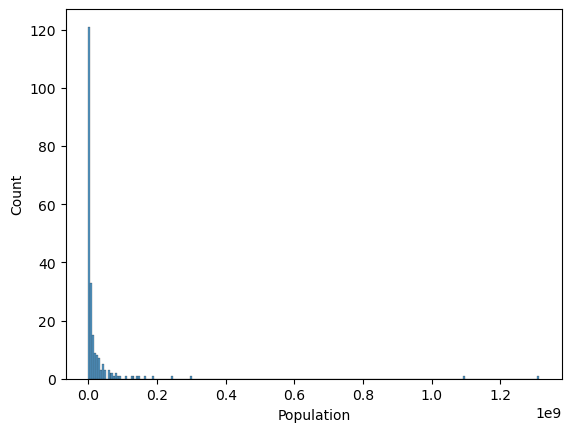

In [6]:
sns.histplot(data=df,x='Population')

**TAAK: Je ziet dat het histogram skewed (scheef) is omwille van een aantal grote landen (India en China zijn extreme outliers).  Reset de X as om enkel landen te tonen die minder dan 0.5 miljard inwoners hebben.**

<Axes: xlabel='Population', ylabel='Count'>

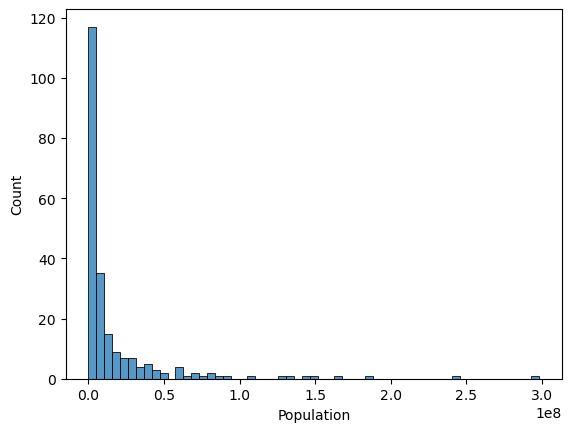

In [7]:
sns.histplot(data=df[df['Population']<500000000],x='Population')

**TAAK: Laat ons nu GDP en Regions bekijken.  Maak een bar chart die het gemiddelde GDP per Capita per region toont.**

In [8]:
df.columns # om zeker de juiste kolomnaam te hebben.

Index(['Country', 'Region', 'Population', 'Area (sq. mi.)',
       'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
       'Net migration', 'Infant mortality (per 1000 births)',
       'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)',
       'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate',
       'Agriculture', 'Industry', 'Service'],
      dtype='object')

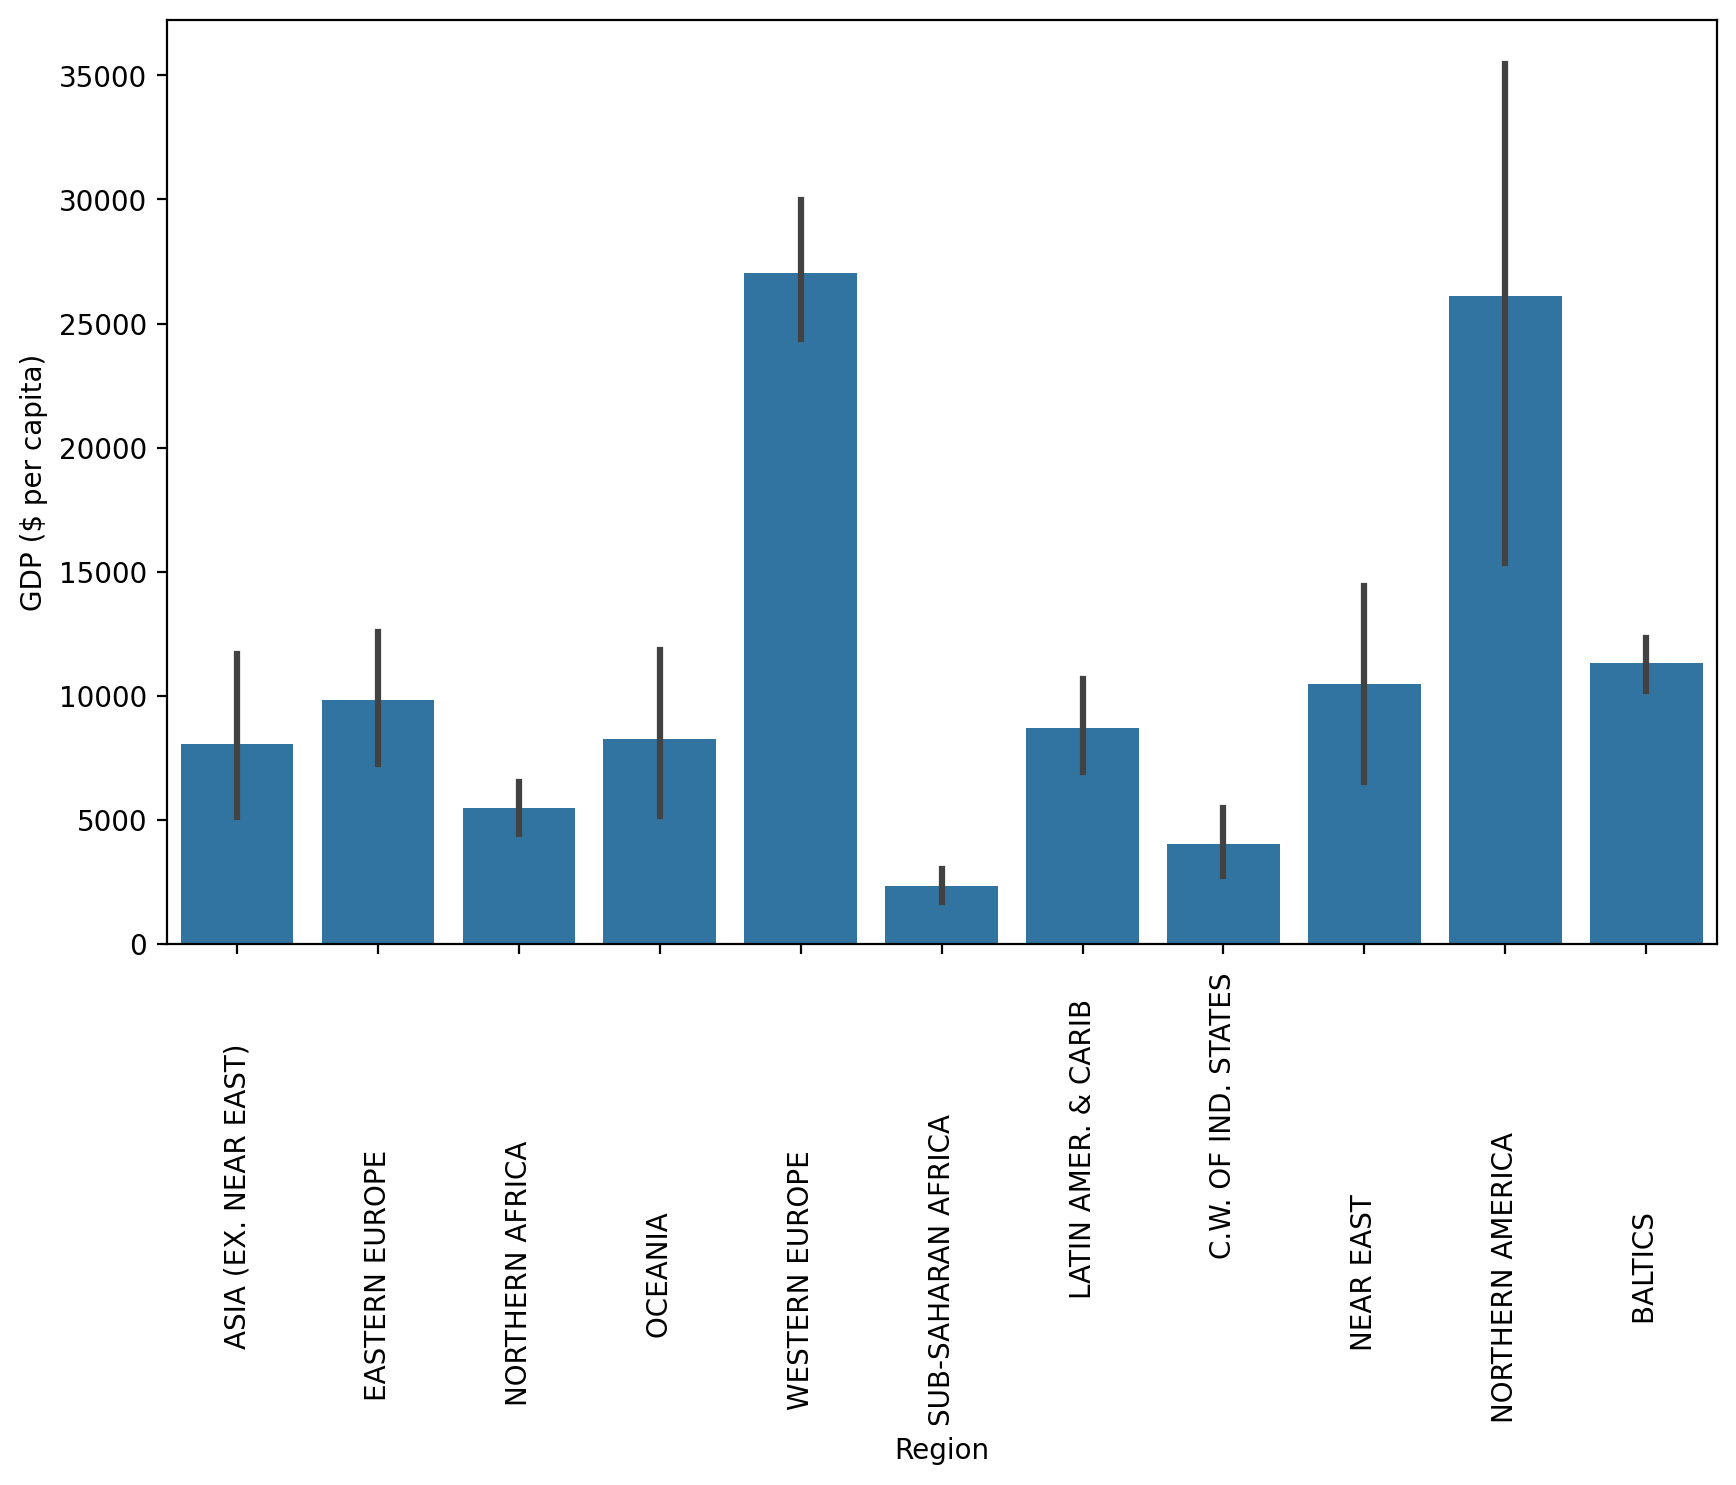

In [9]:
plt.figure(figsize=(10,6),dpi=200)  # groter en betere resolutie
sns.barplot(data=df,y='GDP ($ per capita)',x='Region',estimator=np.mean) # y = continue variabele
plt.xticks(rotation=90);  # roteren van de labels

De zwarte balk geeft de standaardafwijking weer.
<p>Wat valt hier op?  2 regio's hebben een veel hoger GDP per capita dan de rest: West-Europa en Noord-Amerika. De standaardafwijking is in West-Europa veel kleiner dan in Noord-Amerika.  Dit is omdat de Verenigde Staten een veel hoger GDP per capita hebben dan andere Noord-Amerikaanse landen zoals Canada.

**TAAK: Maak een spreidingsdiagram dat de relatie weergeeft tussen het aantal telefoons (Phones) per 1000 mensen en het BBP per capita. Kleur deze punten in op basis van de regio.**

In [10]:
#CODE HERE

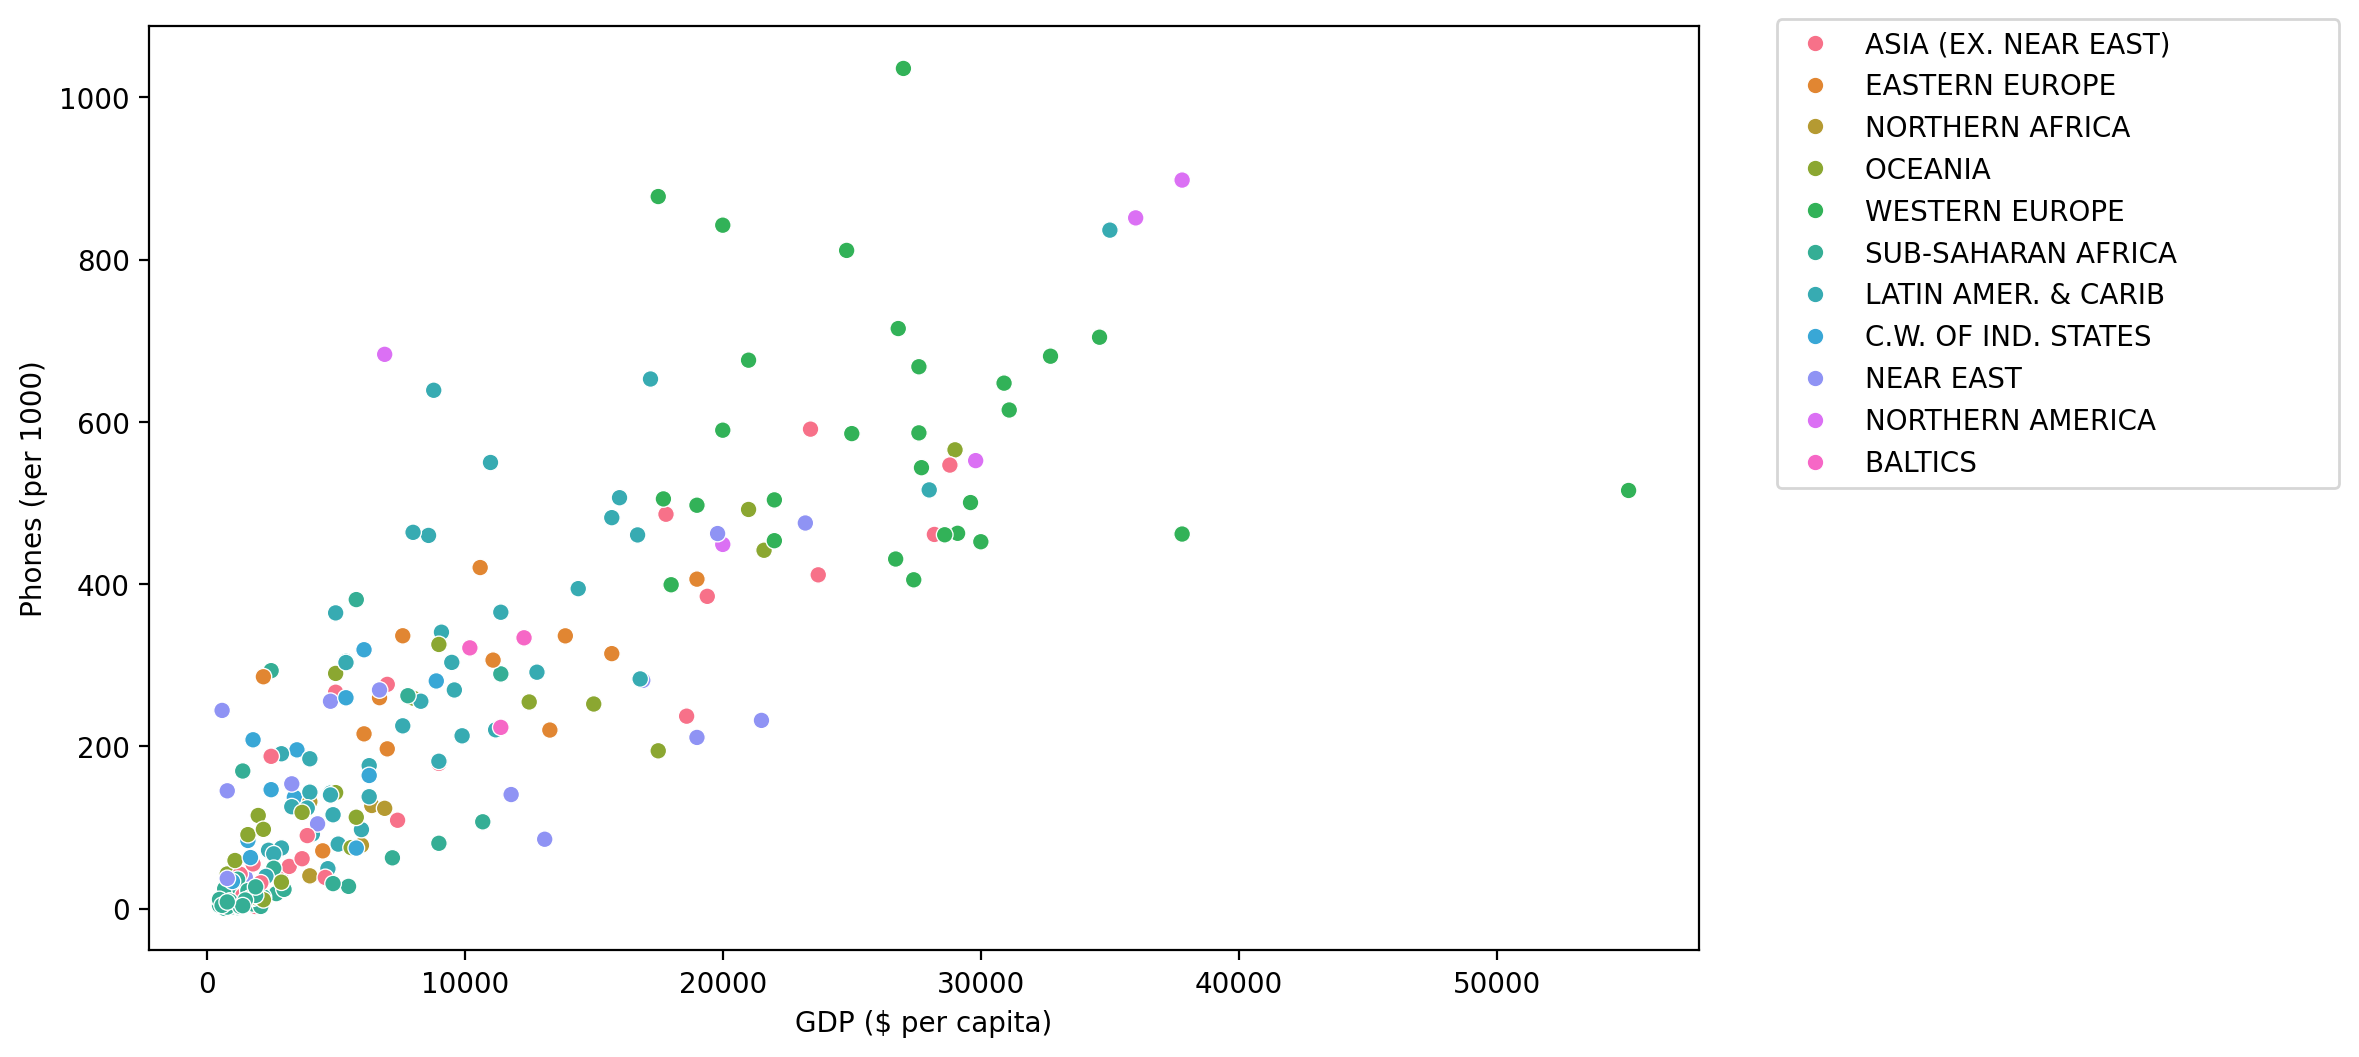

In [11]:
plt.figure(figsize=(10,6),dpi=200)
sns.scatterplot(data=df,x='GDP ($ per capita)',y='Phones (per 1000)',hue='Region')
plt.legend(loc=(1.05,0.5))

Hieruit zien we dat naarmate het GDP per capita hoger is, er meer telefoons per 1000 inwoners zijn. We zien 2 outliers: ééntje helemaal boven, en ééntje helemaal rechts.  Deze boven heeft een hoog GDP per capita, maar heel veel telefoons - meer dan inwoners.  De andere outlier heeft een extreem hoog GDP per capita - het hoogste van de wereld - maar relatief weinig telefoons.  Welke landen zijn dit?

In [12]:
df[df['GDP ($ per capita)']>50000]

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
121,Luxembourg,WESTERN EUROPE,474413,2586,183.5,0.0,8.97,4.81,55100.0,100.0,515.4,23.28,0.4,76.32,NaN,11.94,8.41,0.01,0.13,0.86


In [13]:
df[df['Phones (per 1000)']>1000]

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
138,Monaco,WESTERN EUROPE,32543,2,16271.5,205.0,7.75,5.43,27000.0,99.0,1035.6,0.0,0.0,100.0,NaN,9.19,12.91,0.17,NaN,NaN


**TAAK: Maak een spreidingsdiagram dat de relatie toont tussen het BBP per capita en geletterdheid (kleur de punten op basis van regio). Welke conclusies trek je uit deze grafiek?**

<Axes: xlabel='GDP ($ per capita)', ylabel='Literacy (%)'>

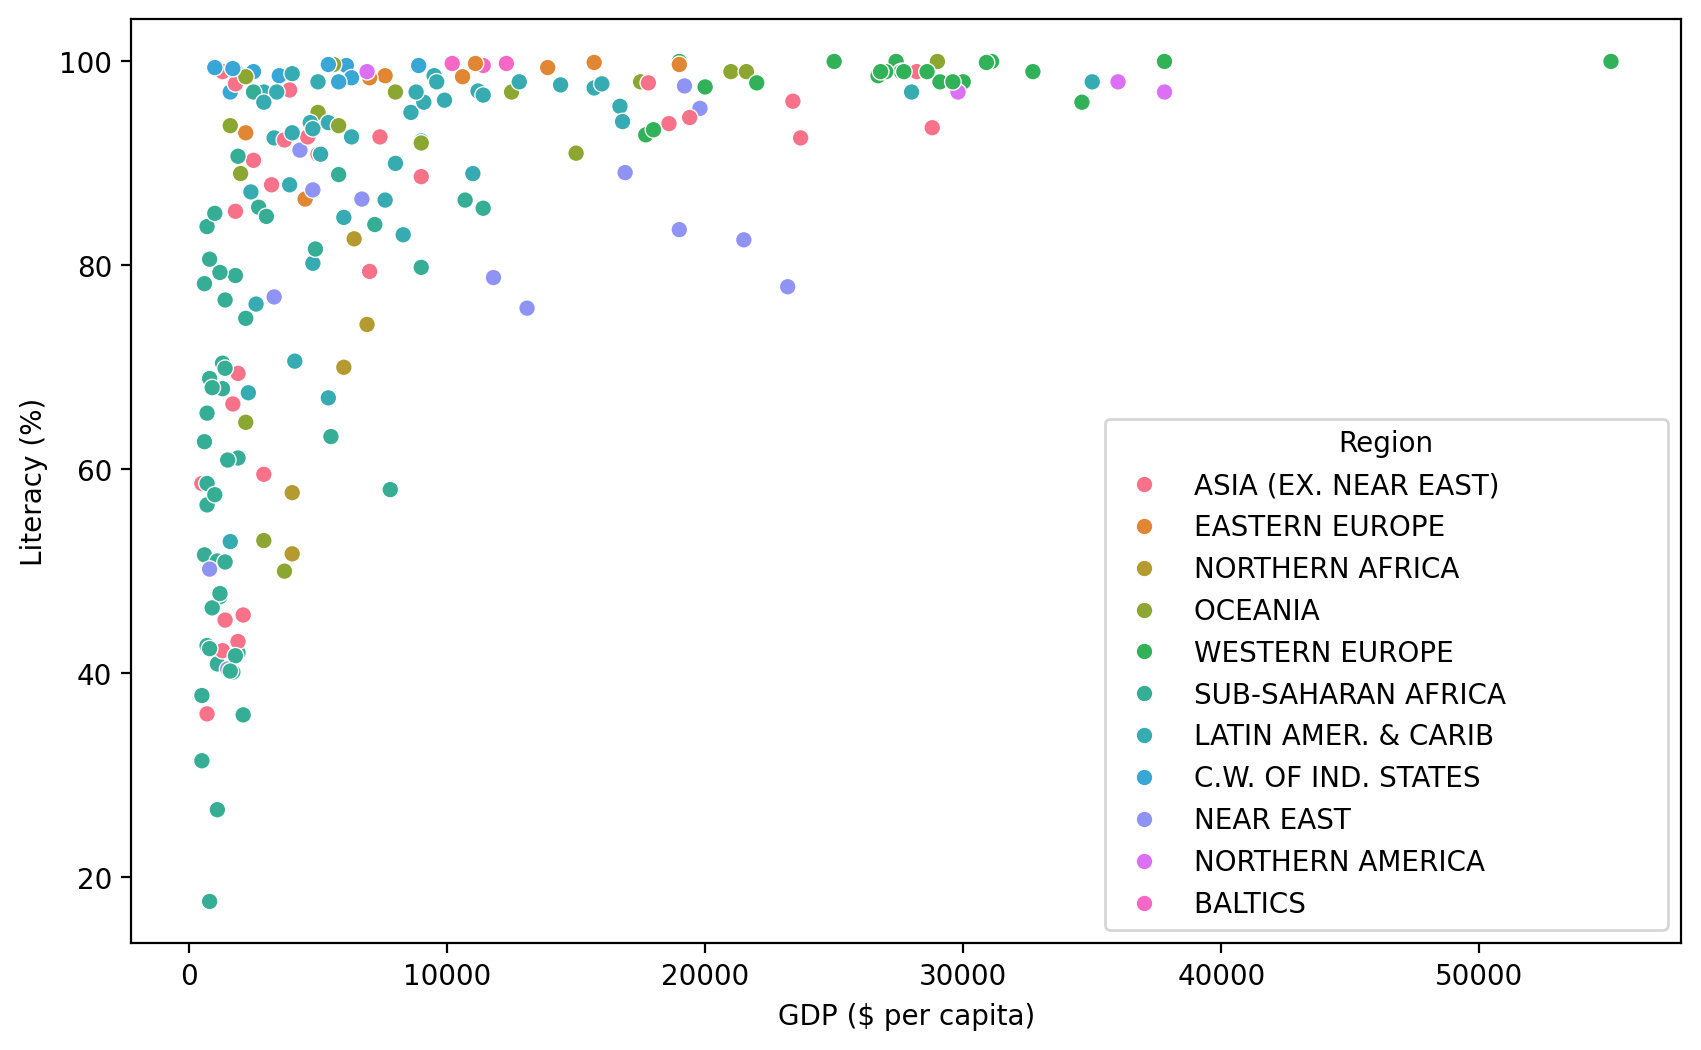

In [14]:
plt.figure(figsize=(10,6),dpi=200)
sns.scatterplot(data=df,x='GDP ($ per capita)',y='Literacy (%)',hue='Region')

**TAAK: Maak een heatmap van de Correlatie tussen kolommen in het DataFrame.**

<Axes: >

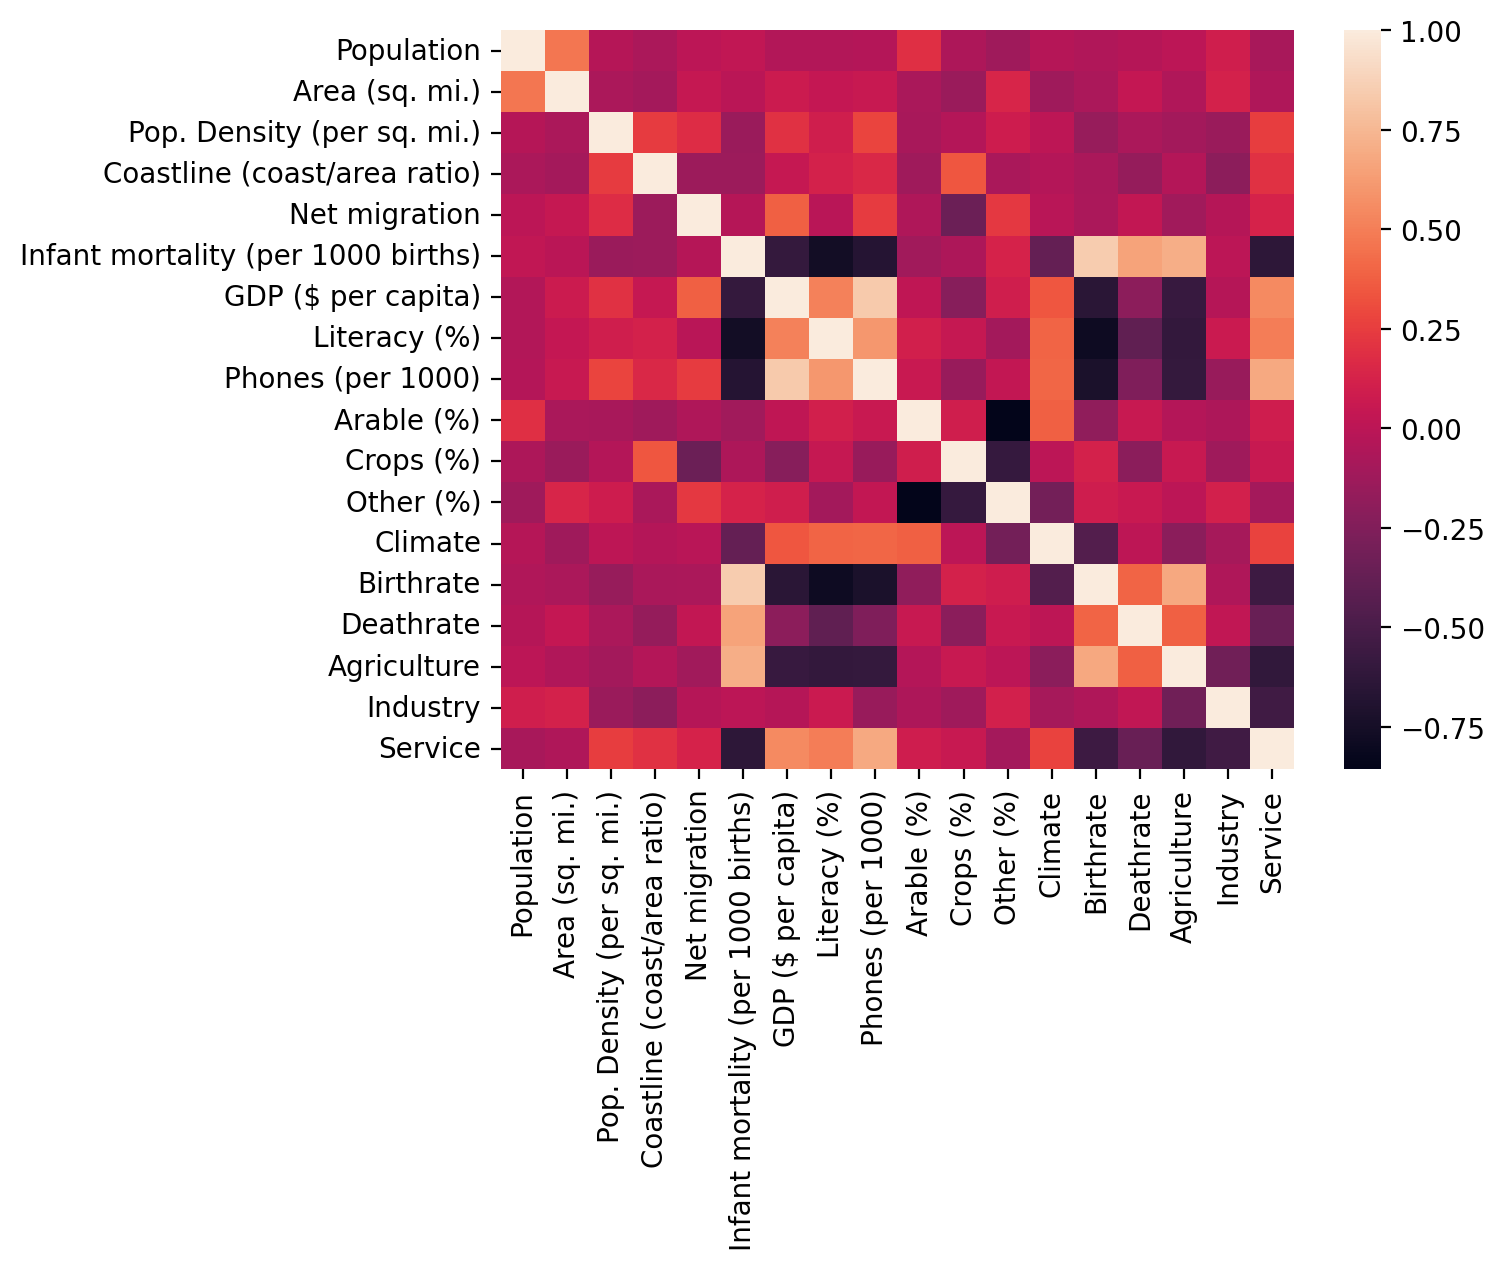

In [15]:
plt.figure(dpi=200)
sns.heatmap(df.corr(numeric_only=True))

Je bemerkt vb een hoge mate van correlatie tussen infant mortality en birthrate.

**TAAK: Seaborn kan op automatische wijze hierarchisch clusteren via de clustermap() functie. Maak een clustermap van de correlaties tussen alle kolommen met behulp van deze functie.**

Dit zien we in de volgende lessen.  Je ziet hier welke features sterk gerelateerd zijn aan elkaar.  Er is een soort features die met leven te maken hebben: deathrate, birthrate, infant mortality (en agriculture).  Daarnaast is er een blok die met rijkdom te maken heeft: Literacy, Service, GDP, Phones.  De kleinere blokken zijn vb klimaatgerelateerd enz.

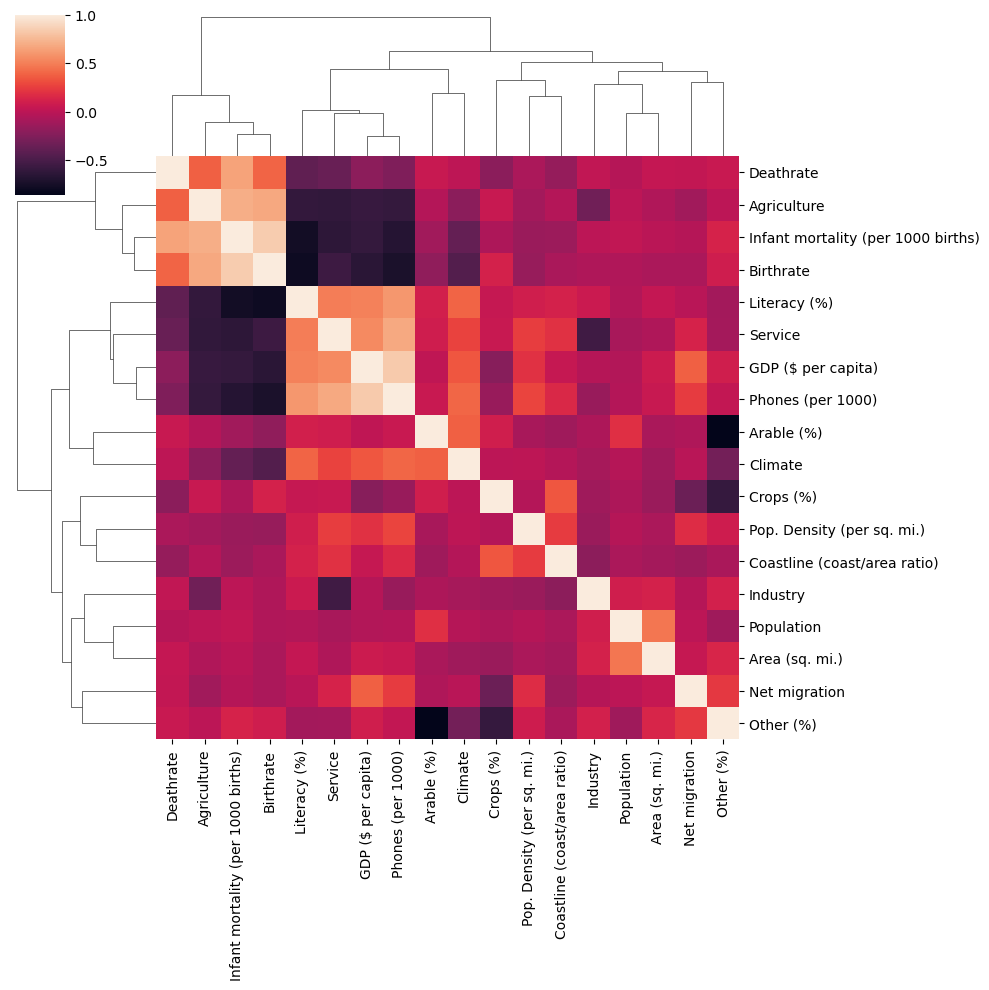

In [16]:
sns.clustermap(df.corr(numeric_only=True))

-----

## Voorbereiding van data en Model

We bereiden nu de data voor om Kmeans Clustering te kunnen toepassen!

### Ontbrekende Data

**TAAK: Geef het aantal ontbrekende elementen per kolom weer.**

Opmerking: KMeans kan niet met ontbrekende waarden om.  De reden hiervoor is dat clusteren gebeurt op basis van afstanden.  Deze afstanden zijn niet te berekenen tussen een punt en NaN.  Daarom moeten we deze nulwaarden wegwerken.

In [17]:
df.isnull().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

Algemeen gezien valt de dataset goed mee.  Op basis van 200 landen kunnen we stellen dat we hier en daar (vb klimaat) ongeveer 10% van de data missen.  We starten dus met de analyse welke landen NaN hebben voor de grotere groepen ontbrekende data.

**TAAK: Welke landen hebben NaN voor Agriculture? Wat is het voornaamste kenmerk van deze landen?**

In [8]:
df[df['Agriculture'].isnull()]['Country']

3            American Samoa
4                   Andorra
78                Gibraltar
80                Greenland
83                     Guam
134                 Mayotte
140              Montserrat
144                   Nauru
153      N. Mariana Islands
171            Saint Helena
174    St Pierre & Miquelon
177              San Marino
208       Turks & Caicos Is
221       Wallis and Futuna
223          Western Sahara
Name: Country, dtype: object

**TAAK: Je zou gemerkt moeten hebben dat de meeste van deze landen kleine eilanden zijn, met uitzondering van Groenland en Westelijke Sahara. Ga je gang en vul eventuele ontbrekende NaN-waarden van deze landen in met 0, aangezien het aandeel agriculture zeer klein of onbestaande zal zijn in deze landen omdat er wellicht geen data over wordt verzameld. Dit zou je in totaal voor 15 landen moeten doen. Voor een hint over hoe je dit kunt doen, herinner je dat je het volgende kunt doen:**

    df[df['feature'].isnull()]
    

In [9]:
# VERWIJDEREN VAN DE KLEINE EILANDEN
df[df['Agriculture'].isnull()] = df[df['Agriculture'].isnull()].fillna(0)

**TAAK: Controleer nu wat er nog ontbreekt door opnieuw het aantal ontbrekende elementen per feature te tellen:**

In [20]:
df.isnull().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                               18
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

Opmerking: we hebben de kolommen waar ontbrekende waarden voor Agriculture waren aangevuld.  We hebben dus voor de kleine (ei)landen de ontbrekende waarden (waaronder Agriculture) aangevuld.  Op zich zijn ook de ontbrekende waarden voor Industry en Service hierdoor aangevuld!  Dit is te verantwoorden gezien het feit dat veel van die landen klein zijn.

**TAAK: Merk op dat het klimaat ontbreekt voor een aantal landen, maar niet de Regio! Laten we dit gebruiken door de ontbrekende klimaatwaarden in te vullen op basis van de gemiddelde klimaatwaarde voor de betreffende regio.**

Hints hoe je dit kan doen: https://stackoverflow.com/questions/19966018/pandas-filling-missing-values-by-mean-in-each-group

De functie fillna() vervangt alleen de NaN (ontbrekende) waarden in de 'Climate' kolom met de waarden die berekend worden door df.groupby('Region')['Climate'].transform('mean'). Dit betekent dat het de gemiddelde 'Climate'-waarde van de respectievelijke regio zal gebruiken waarvoor de 'Climate'-waarde ontbreekt.

In [10]:
df['Climate'] = df['Climate'].fillna(df.groupby('Region')['Climate'].transform('mean'))

**TAAK: Controleer opnieuw hoeveel ontbrekende waarden er zijn per feature:**

In [11]:
df.isnull().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                                0
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

**TAAK: Het lijkt erop dat het percentage geletterdheid ontbreekt. Gebruik dezelfde tactiek als we deden met ontbrekende klimaatwaarden en vul eventuele ontbrekende waarden voor het percentage geletterdheid in met het gemiddelde percentage geletterdheid van de regio.**

In [12]:
df[df['Literacy (%)'].isnull()]

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
25,Bosnia & Herzegovina,EASTERN EUROPE,4498976,51129,88.0,0.04,0.31,21.05,6100.0,NaN,215.4,13.60,2.96,83.44,4.000000,8.77,8.27,0.142,0.308,0.550
66,Faroe Islands,WESTERN EUROPE,47246,1399,33.8,79.84,1.41,6.24,22000.0,NaN,503.8,2.14,0.00,97.86,2.826087,14.05,8.70,0.270,0.110,0.620
74,Gaza Strip,NEAR EAST,1428757,360,3968.8,11.11,1.60,22.93,600.0,NaN,244.3,28.95,21.05,50.00,3.000000,39.45,3.80,0.030,0.283,0.687
85,Guernsey,WESTERN EUROPE,65409,78,838.6,64.10,3.84,4.71,20000.0,NaN,842.4,NaN,NaN,NaN,3.000000,8.81,10.01,0.030,0.100,0.870
99,Isle of Man,WESTERN EUROPE,75441,572,131.9,27.97,5.36,5.93,21000.0,NaN,676.0,9.00,0.00,91.00,3.000000,11.05,11.19,0.010,0.130,0.860
104,Jersey,WESTERN EUROPE,91084,116,785.2,60.34,2.76,5.24,24800.0,NaN,811.3,0.00,0.00,100.00,3.000000,9.30,9.28,0.050,0.020,0.930
108,Kiribati,OCEANIA,105432,811,130.0,140.94,0.00,48.52,800.0,NaN,42.7,2.74,50.68,46.58,2.000000,30.65,8.26,0.089,0.242,0.668
123,Macedonia,EASTERN EUROPE,2050554,25333,80.9,0.00,-1.45,10.09,6700.0,NaN,260.0,22.26,1.81,75.93,3.000000,12.02,8.77,0.118,0.319,0.563
185,Slovakia,EASTERN EUROPE,5439448,48845,111.4,0.00,0.30,7.41,13300.0,NaN,220.1,30.16,2.62,67.22,3.000000,10.65,9.45,0.035,0.294,0.672
187,Solomon Islands,OCEANIA,552438,28450,19.4,18.67,0.00,21.29,1700.0,NaN,13.4,0.64,2.00,97.36,2.000000,30.01,3.92,0.420,0.110,0.470


In [13]:
df['Literacy (%)'] = df['Literacy (%)'].fillna(df.groupby('Region')['Literacy (%)'].transform('mean'))

**TAAK: Controleer opnieuw de ontbrekende waarden:**

In [14]:
df.isnull().sum()

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         1
Infant mortality (per 1000 births)    1
GDP ($ per capita)                    0
Literacy (%)                          0
Phones (per 1000)                     2
Arable (%)                            1
Crops (%)                             1
Other (%)                             1
Climate                               0
Birthrate                             1
Deathrate                             2
Agriculture                           0
Industry                              1
Service                               1
dtype: int64

**TAAK: Optioneel: We missen nu alleen nog waarden voor een paar landen. Ga je gang en verwijder deze landen of vul deze laatste paar ontbrekende waarden in met een door jou gekozen methode. Voor de eenvoud zullen we deze landen verwijderen.**

In [15]:
df = df.dropna()

## Data Feature Voorbereiding

**TAAK: Het is nu tijd om de gegevens voor clustering voor te bereiden. De kolom Country is nog steeds een unieke identificatie string; het is niet echt een feature maar eerder een label.  Deze is niet nuttig voor clustering, aangezien het Land uniek is voor elk punt. Ga je gang en verwijder deze kolom Land.**

In [16]:
X = df.drop("Country",axis=1)

**TAAK: Laten we nu de X feature array creëren.   De kolom Regio bestaat nog steeds uit categorische strings. Gebruik Pandas om dummyvariabelen van deze kolom te maken om een gefinaliseerde X-matrix van continue features te creëren, samen met de dummyvariabelen voor de Regio's.**

In [17]:
X = pd.get_dummies(X)

In [18]:
X.head()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_BALTICS,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,...,False,False,False,False,False,False,False,False,False,False
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,...,False,False,True,False,False,False,False,False,False,False
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,...,False,False,False,False,False,True,False,False,False,False
3,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,...,False,False,False,False,False,False,False,True,False,False
4,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,...,False,False,False,False,False,False,False,False,False,True


### Scaling

**TAAK: Aangezien sommige metingen in % zijn en andere total counts zijn (populatie), moeten we de data schalen.  Gebruik Sklearn om de X features te schalen.**

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [29]:
scaled_X

array([[ 0.0133285 ,  0.01855412, -0.20308668, ..., -0.31544015,
        -0.54772256, -0.36514837],
       [-0.21730118, -0.32370888, -0.14378531, ..., -0.31544015,
        -0.54772256, -0.36514837],
       [ 0.02905136,  0.97784988, -0.22956327, ..., -0.31544015,
        -0.54772256, -0.36514837],
       ...,
       [-0.06726127, -0.04756396, -0.20881553, ..., -0.31544015,
        -0.54772256, -0.36514837],
       [-0.15081724,  0.07669798, -0.22840201, ..., -0.31544015,
         1.82574186, -0.36514837],
       [-0.14464933, -0.12356132, -0.2160153 , ..., -0.31544015,
         1.82574186, -0.36514837]], shape=(221, 29))

### Maken en Fitten van een Kmeans Model

**TAAK: Gebruik een for-loop om meerdere KMeans-modellen te creëren en te fitten, waarbij je test van K=2 tot K=30 clusters. Houd de som van de gekwadrateerde afstanden bij voor elke K-waarde en plot deze om een "elleboog"-grafiek te maken van K versus SSD. Optioneel: Je kunt ook een staafdiagram maken dat het verschil in SSD toont ten opzichte van de vorige cluster.**

In [24]:
from sklearn.cluster import KMeans

In [34]:
ssd = []

for k in range(2,30):    
    model = KMeans(n_clusters=k, n_init='auto')      
    model.fit(scaled_X)
    
    #Som v/d squared distances van samples tot hun dichtste centroïde
    ssd.append(model.inertia_)

Text(0, 0.5, ' Sum of Squared Distances')

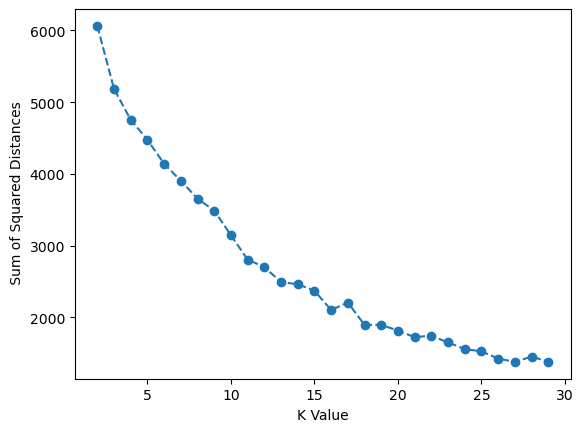

In [35]:
plt.plot(range(2,30),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")

<Axes: >

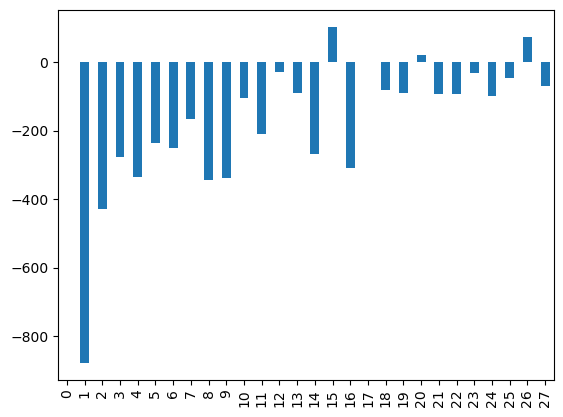

In [36]:
pd.Series(ssd).diff().plot(kind='bar')

-----

# Interpretatie van het Model


**Welke K-waarde denk je dat een goede keuze is? Zijn er meerdere redelijke keuzes? Welke kenmerken helpen bij het definiëren van deze clusterkeuzes? Aangezien dit unsupervised learning is, is er hier geen 100% correct antwoord.**

Voor elke keuze van K kan je een model trainen, en vervolgens kan je de analyse doen inzake correlatie enz...

-----


#### Voorbeeld interpretatie: Kies K=3

**Men zou kunnen zeggen dat er een aanzienlijke afname is in het SSD-verschil bij K=3 (hoewel we kunnen zien dat het daarna blijft afnemen). Hoe zou een analyse eruitzien voor K=3? Laten we onderzoeken welke kenmerken belangrijk zijn in de beslissing van 3 clusters.!**

In [ ]:
model = KMeans(n_clusters=3, n_init='auto', random_state=42)
model.fit(scaled_X)

KMeans(n_clusters=3, n_init='auto', random_state=42)

In [83]:
model.labels_

array([0, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 0, 1, 2, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 2, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 2, 0, 1, 0, 1,
       1, 1, 1, 2, 1, 1, 0, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0], dtype=int32)

In [84]:
# voeg een nieuwe kolom 'K=3 Clusters' toe aan de dataset:
X['K=3 Clusters'] = model.labels_

In [85]:
X.head()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE,K=3 Clusters
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,...,False,False,False,False,False,False,False,False,False,0
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,...,False,True,False,False,False,False,False,False,False,1
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,...,False,False,False,False,True,False,False,False,False,1
3,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,...,False,False,False,False,False,False,True,False,False,1
4,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,...,False,False,False,False,False,False,False,False,True,1


In [86]:
# bepaal nu de correlatie tussen de features van X:
overview = X.corr()
overview

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE,K=3 Clusters
Population,1.000000,0.468970,-0.023430,-0.066074,0.002533,0.022362,-0.036742,-0.018654,-0.022118,0.189811,...,-0.012328,-0.037312,-0.072089,-0.037412,-0.003601,0.047081,-0.073646,-0.067927,-0.043613,-0.046968
Area (sq. mi.),0.468970,1.000000,-0.068970,-0.092893,0.051243,-0.008951,0.076644,0.032528,0.068821,-0.079679,...,0.162735,-0.065482,-0.044031,-0.048392,0.035964,0.314969,-0.032800,-0.041409,-0.095184,0.092967
Pop. Density (per sq. mi.),-0.023430,-0.068970,1.000000,0.174995,0.143012,-0.137546,0.159220,0.014816,0.172743,-0.047342,...,-0.047048,-0.037194,-0.068163,0.029157,-0.035099,-0.005827,-0.043235,-0.092466,0.016076,0.063384
Coastline (coast/area ratio),-0.066074,-0.092893,0.174995,1.000000,-0.158043,-0.128234,0.028633,0.028851,0.110938,-0.112760,...,-0.067126,-0.060819,-0.030024,-0.063281,-0.046276,0.062182,0.397052,-0.115267,-0.013324,0.100422
Net migration,0.002533,0.051243,0.143012,-0.158043,1.000000,-0.016508,0.372248,-0.006267,0.215494,-0.055470,...,-0.099444,-0.027023,-0.153968,0.155383,-0.012000,-0.008246,-0.126006,-0.036549,0.235211,-0.050417
Infant mortality (per 1000 births),0.022362,-0.008951,-0.137546,-0.128234,-0.016508,1.000000,-0.588040,-0.585930,-0.662259,-0.110148,...,0.059212,-0.148088,-0.221423,-0.084986,-0.046467,-0.115760,-0.146120,0.685075,-0.318184,-0.667342
GDP ($ per capita),-0.036742,0.076644,0.159220,0.028633,0.372248,-0.588040,1.000000,0.428451,0.843923,0.041037,...,-0.133416,0.021152,-0.045071,0.008050,-0.083837,0.251120,-0.036694,-0.396679,0.647154,0.338014
Literacy (%),-0.018654,0.032528,0.014816,0.028851,-0.006267,-0.585930,0.428451,1.000000,0.453620,0.169221,...,0.184557,0.163559,0.210094,-0.034222,-0.184800,-0.020072,0.029718,-0.479493,0.207184,0.597386
Phones (per 1000),-0.022118,0.068821,0.172743,0.110938,0.215494,-0.662259,0.843923,0.453620,1.000000,0.084955,...,-0.069128,0.055536,0.088870,-0.022134,-0.109423,0.319002,-0.060736,-0.461185,0.566584,0.456591
Arable (%),0.189811,-0.079679,-0.047342,-0.112760,-0.055470,-0.110148,0.041037,0.169221,0.084955,1.000000,...,0.104623,0.298494,-0.115162,-0.062551,-0.081039,-0.027241,-0.159167,-0.092660,0.107081,0.076741


In [87]:
# Check nu, voor K = 3, welke features sterk met elkaar gecorreleerd zijn.  
overview['K=3 Clusters'].sort_values()

Region_SUB-SAHARAN AFRICA                    -0.730902
Birthrate                                    -0.693284
Infant mortality (per 1000 births)           -0.667342
Deathrate                                    -0.532784
Agriculture                                  -0.489077
Region_ASIA (EX. NEAR EAST)                  -0.082083
Net migration                                -0.050417
Population                                   -0.046968
Other (%)                                    -0.042955
Industry                                      0.026817
Region_NEAR EAST                              0.042871
Crops (%)                                     0.047754
Region_BALTICS                                0.048270
Region_NORTHERN AMERICA                       0.062604
Pop. Density (per sq. mi.)                    0.063384
Region_NORTHERN AFRICA                        0.068739
Arable (%)                                    0.076741
Area (sq. mi.)                                0.092967
Region_EAS

<Axes: >

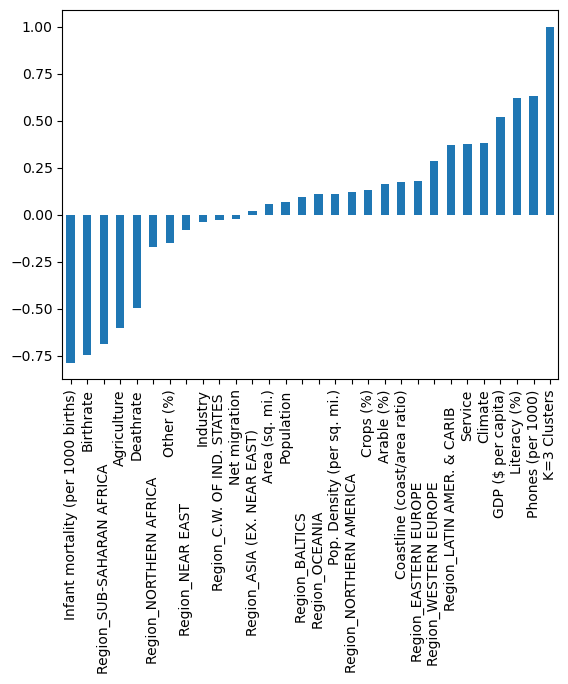

In [81]:
X.corr()['K=3 Clusters'].sort_values().plot(kind='bar')

We hebben nu 3 clusters, en de plot geeft weer welke impact features hebben om tot een bepaalde cluster te horen.  Hier zien we aan de ene kant de features die te maken hebben met "leven", en aan de andere kant de eerder economische features.  Een betere manier om dit weer te geven zou echter zijn om dit op basis van een wereldkaart te tonen - zie de bonusvraag.

### Dieper in de cluster zelf: hoe hangen de verschillende features **binnen een bepaalde cluster** samen?

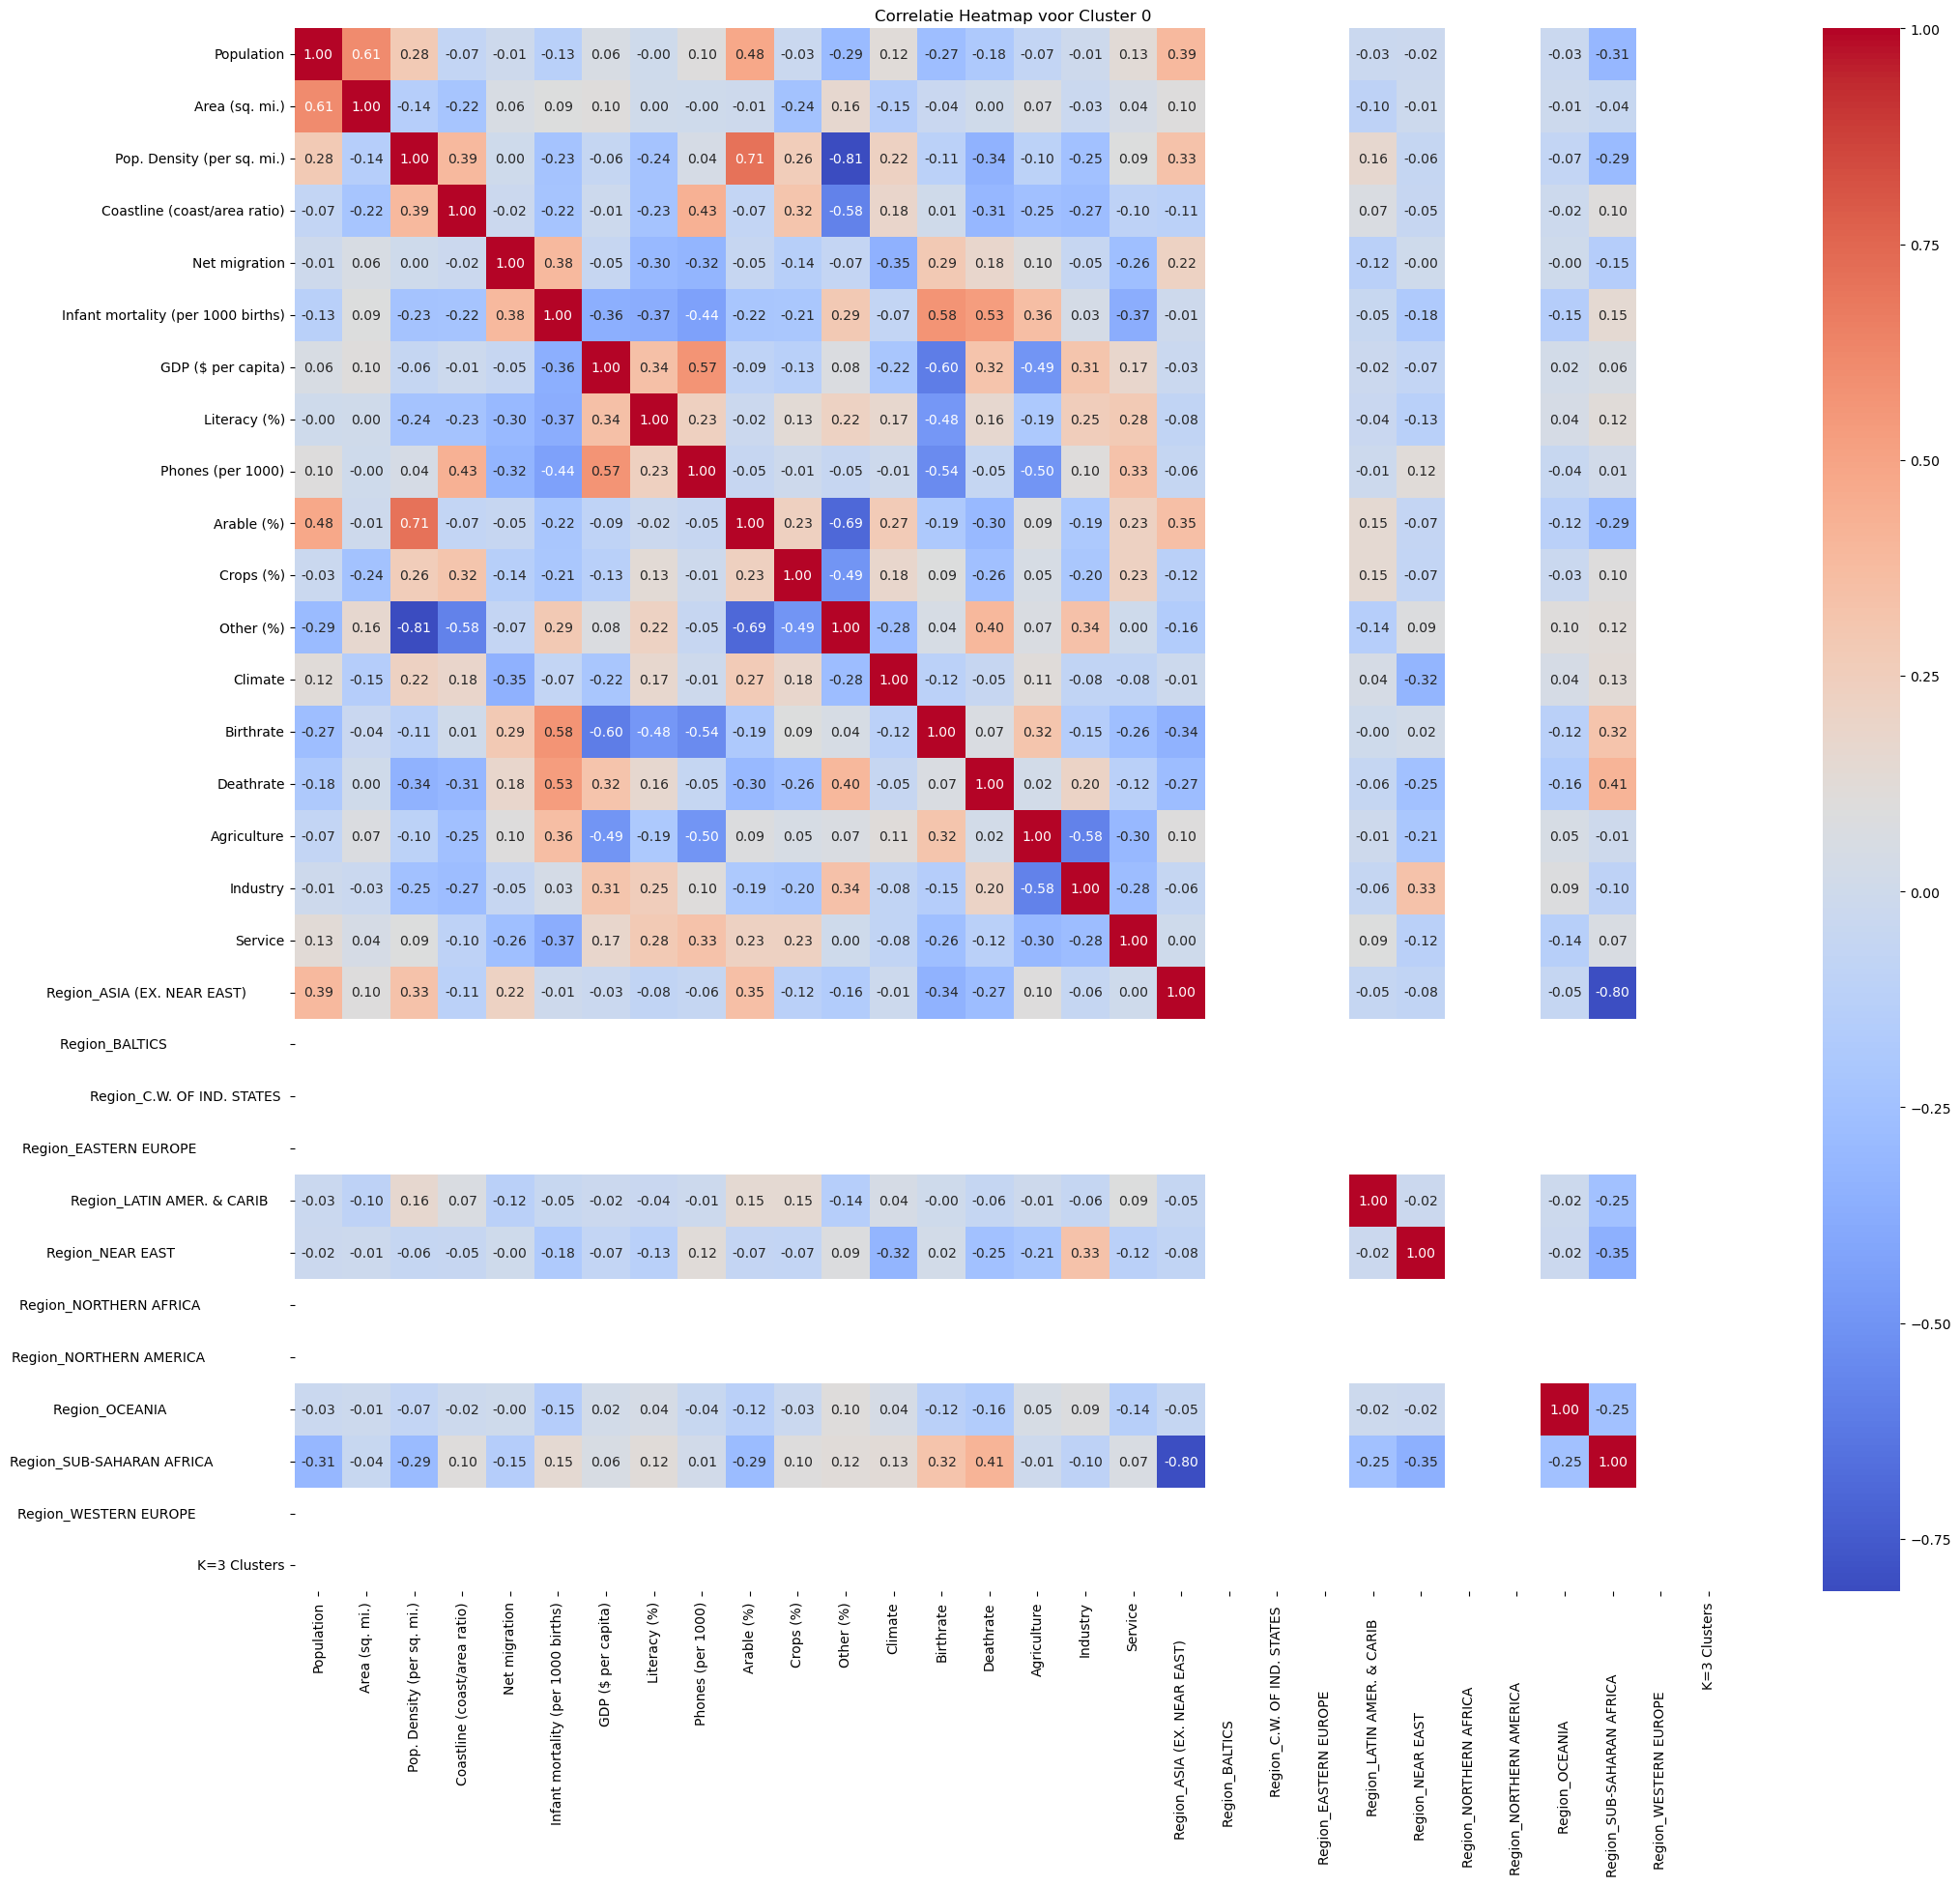

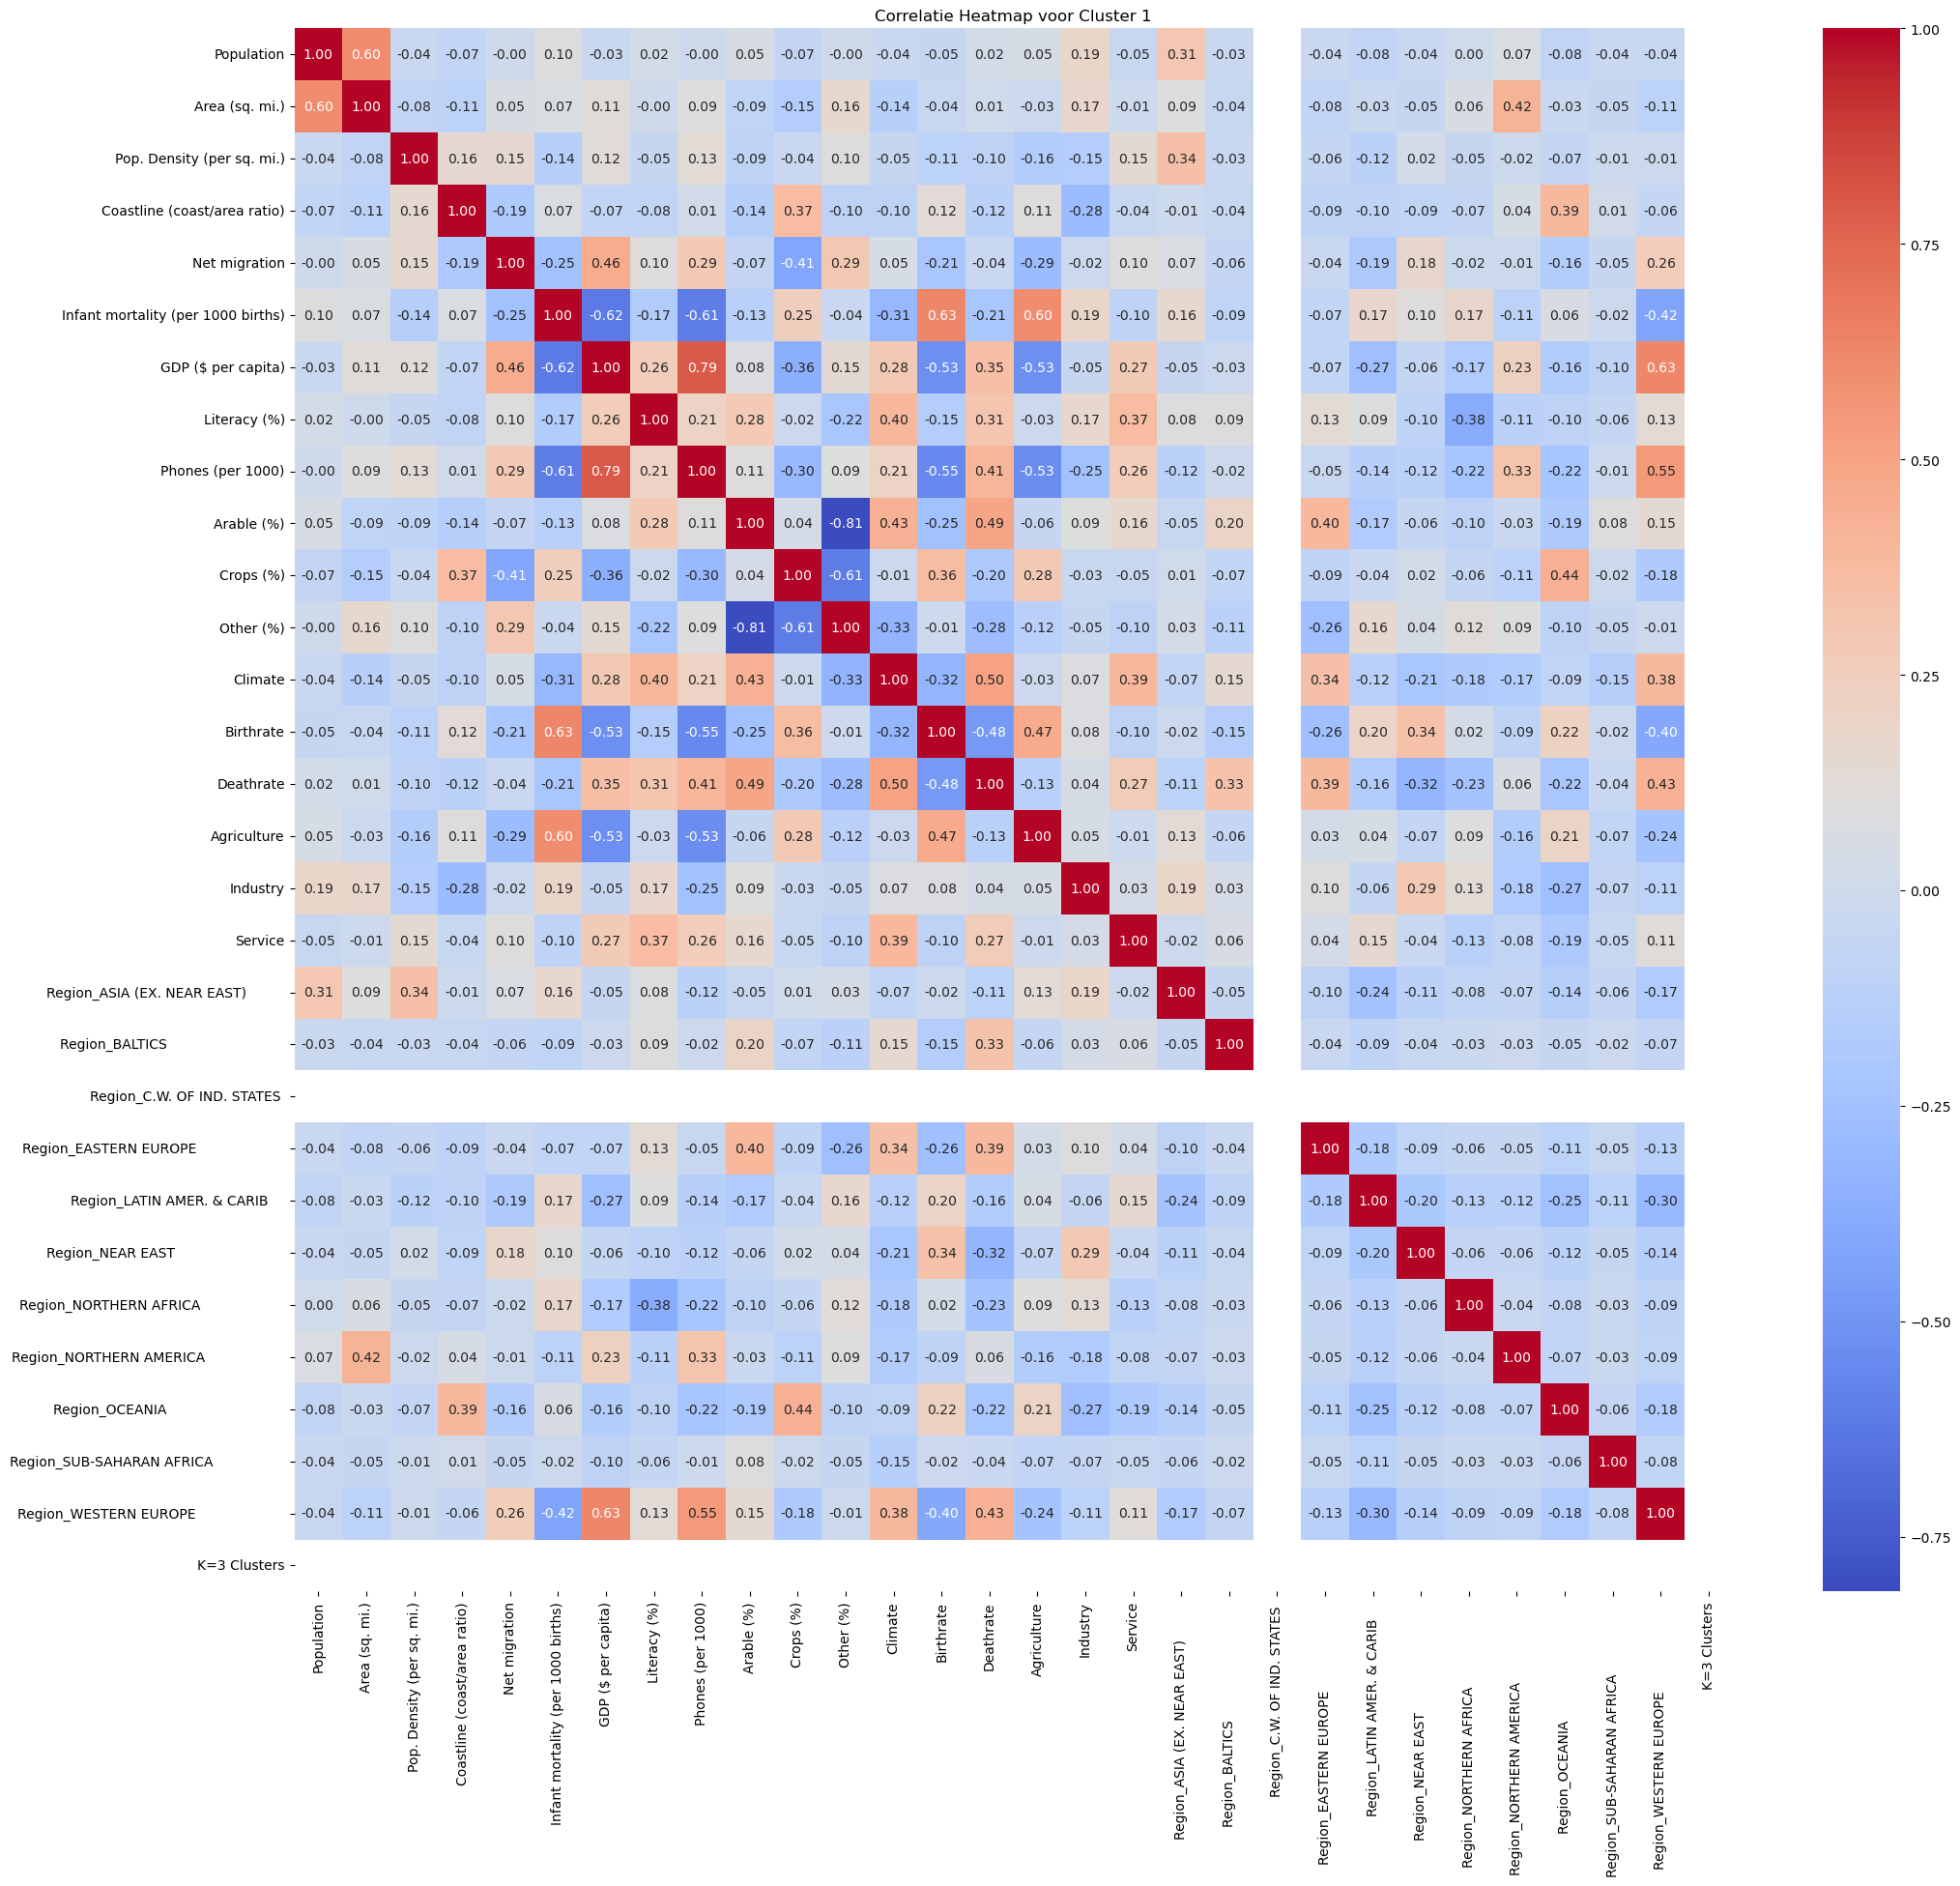

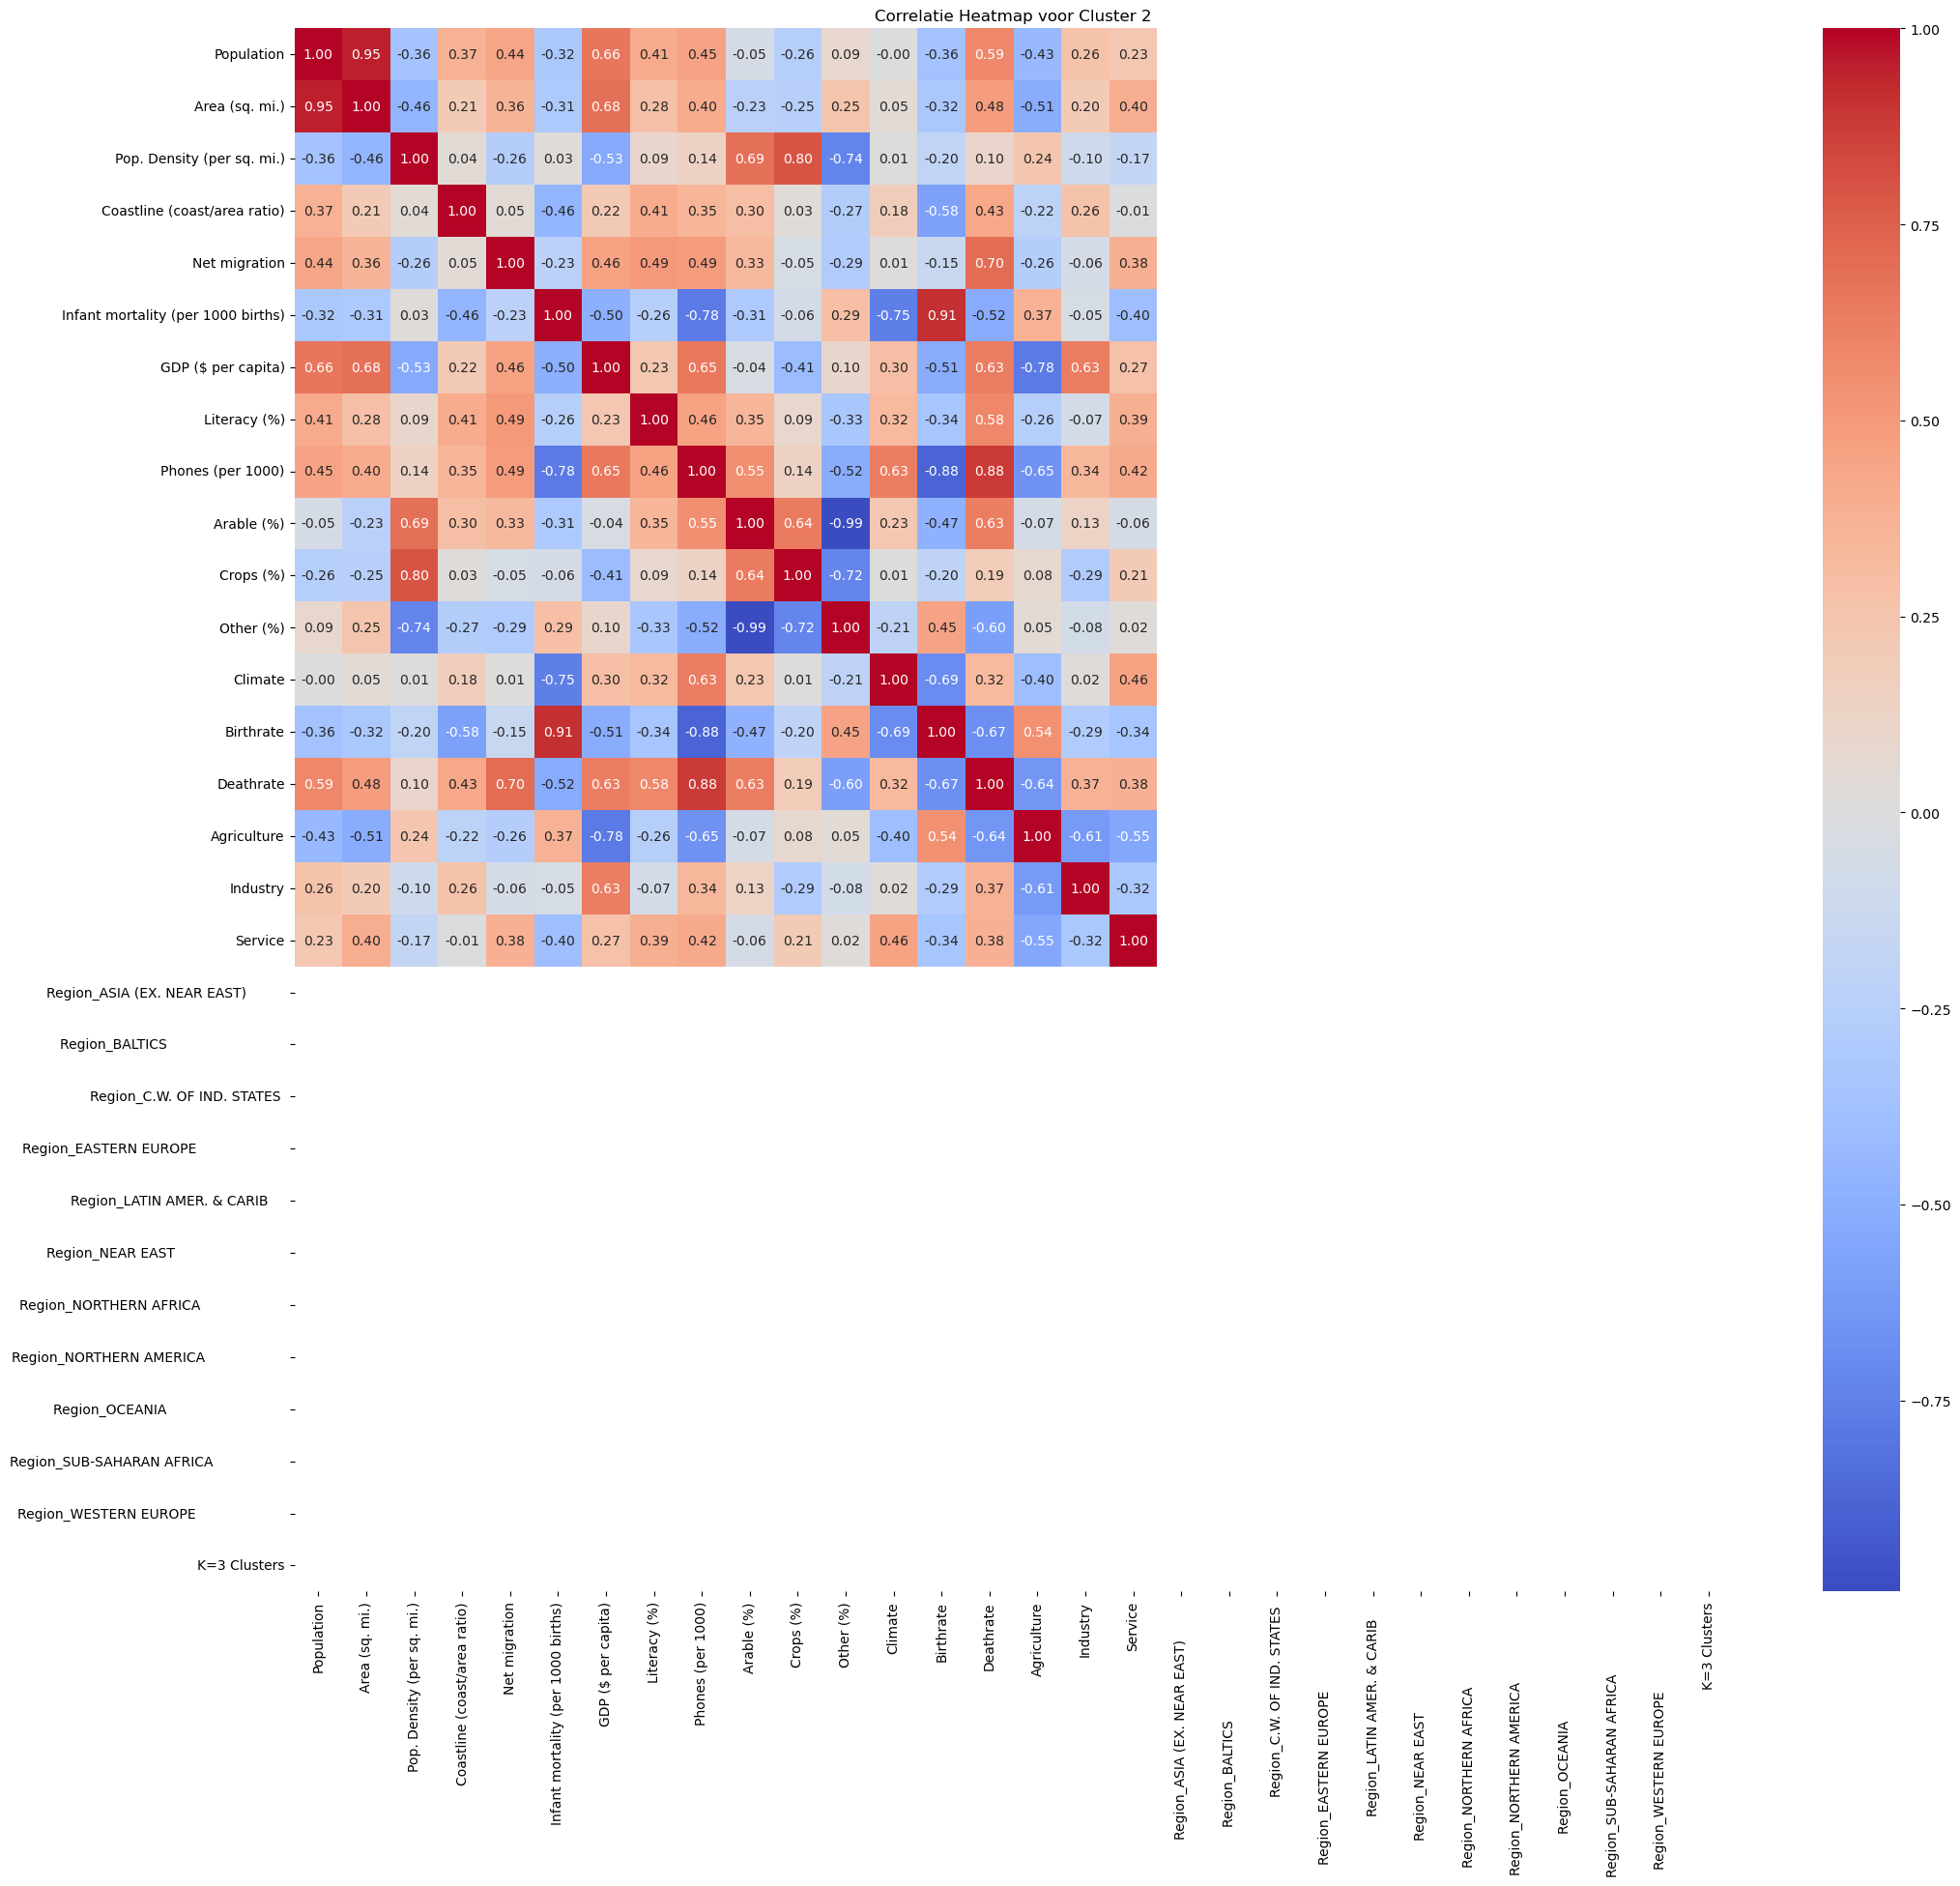

In [67]:
# Loop over elk clusterlabel
for label in X['K=3 Clusters'].unique():
    # Filter de data voor het huidige cluster
    cluster_data = X[X['K=3 Clusters'] == label]

    # Bereken de correlatie binnen deze cluster
    correlation = cluster_data.corr()

    # Maak een nieuwe figuur voor elke heatmap
    plt.figure(figsize=(24, 21))
    
    # Maak een heatmap voor de correlatiematrix
    sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(f'Correlatie Heatmap voor Cluster {label}')
    plt.show()

In [45]:
# Analyse van de centroïden

centroids = model.cluster_centers_
centroid_df = pd.DataFrame(centroids, columns=X.columns[:-1])    # X.columns[:-1] weg: dit is de laatste kolom, zijnde de 3 clusters...
centroid_df

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_BALTICS,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE
0,-0.054777,0.107692,0.535041,0.088370,0.678097,-0.846633,1.687390,0.515627,1.563061,0.078463,...,-0.117309,-0.239617,-0.228869,-0.328271,-0.269844,-0.167054,0.648428,-0.149459,-0.547723,1.556228
1,0.059304,-0.014650,-0.102958,0.072055,-0.265030,-0.298466,-0.251734,0.234168,-0.136417,0.063136,...,0.083662,0.170890,0.163224,0.302867,0.161627,0.119139,-0.152145,0.170925,-0.437329,-0.365148
2,-0.106991,-0.052665,-0.183802,-0.260132,0.114177,1.481214,-0.767934,-1.037281,-0.961015,-0.228800,...,-0.117309,-0.239617,-0.228869,-0.505650,-0.190330,-0.167054,-0.152145,-0.315440,1.588395,-0.365148


### Elke centroïde kan worden gezien als een algemene maat voor de cluster locatie en helpen met de interpretatie van de cluster.  
<p>Cluster 0: hogere bevolkinsdichtheid, er wordt vooral gemigreerd naar deze landen, lage kindersterfte, hoge geletterdheid, veel telefoons (infrastructuur...), veel bewerkbaar gebied, ...</p>
<p>Cluster 1: weinig kustlijn, hoge kindersterfte, arm, veel ongeletterdheid, weinig telefoons (infrastructuur...), ...</p>
<p>Cluster 2: veel kustlijn (eilanden), veel uitgaande migratie, ...</p>

------------
-------------

# BONUS UITDAGING:
## Geografische Interpretatie van het model

**De beste manier om dit model te interpreteren is door de clusters van landen op een kaart te visualiseren.** 

**TAAK: Maak cluster labels voor een gekozen K-waarde. Op basis van de oplossingen denken we dat K=3 of K=15 redelijke keuzes zijn. Maar voel je vrij om anders te kiezen en verder te verkennen.**

In [46]:
model = KMeans(n_clusters=15, n_init='auto')
    
model.fit(scaled_X)

KMeans(n_clusters=15, n_init='auto')

In [30]:
model = KMeans(n_clusters=3, n_init='auto')
    
model.fit(scaled_X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


**TAAK: Zet de clusters op een landelijke choropleetkaart uit. Je moet hiervoor het volgende doen:**

1. Zoek uit hoe je de Plotly-bibliotheek kunt installeren: https://plotly.com/python/getting-started/

2. Zoek uit hoe je een geografische choropleetkaart kunt maken met Plotly: https://plotly.com/python/choropleth-maps/#using-builtin-country-and-state-geometries

3. Je hebt ISO-codes nodig voor dit. Gebruik de Wikipedia-pagina of gebruik het volgende bestand hiervoor: "../DATA/country_iso_codes.csv"

4. Combineer de clusterlabels, ISO-codes en landnamen om een wereldkaartplot met Plotly te maken met wat je hebt geleerd in stap 1 en stap 2.

Opmerking: Dit is bedoeld als een realistischer project, waarbij je een duidelijk doel hebt van wat je moet creëren en bereiken en de benodigde online documentatie. Het is aan jou om alles samen te voegen en uit te zoeken! Als je vastloopt: geen zorgen! Alles komt online met de oplossing.

In [48]:
# 01 Installatie Plotly

!pip install "jupyterlab>=3" "ipywidgets>=7.6"
!pip install jupyter-dash

In [19]:
# 03 ISO-codes inladen
import pandas as pd

iso_codes = pd.read_csv("../data/country_iso_codes.csv")
iso_codes

,Country,ISO Code
0,Afghanistan,AFG
1,"Akrotiri and Dhekelia – See United Kingdom, The","Akrotiri and Dhekelia – See United Kingdom, The"
2,Åland Islands,ALA
3,Albania,ALB
4,Algeria,DZA
...,...,...
296,"Congo, Dem. Rep.",COD
297,"Congo, Repub. of the",COG
298,Tanzania,TZA
299,Central African Rep.,CAF


In [20]:
# MAAK EEN DICTIONARY VAN DE iso_codes
# In ons initieel dataframe hebben we de landnaam.  We willen op basis van de landnaam ook de ISO code toevoegen.  
# Daarom willen we een dict maken die deze beide zaken koppelt.
iso_mapping = iso_codes.set_index('Country')['ISO Code'].to_dict()

# Hoe dit gebeurt:
# .set_index : stel de DataFrame index (rij labels) in op een bestaande kolom of array van dezelfde lengte, in dit geval de kolom 'Country'
# ['ISO Code'] : selecteer de kolom ISO Code
# .to_dict: maak er een Python dictionary van

In [4]:
iso_mapping

{'Afghanistan': 'AFG',
 'Akrotiri and Dhekelia – See United Kingdom, The': 'Akrotiri and Dhekelia – See United Kingdom, The',
 'Åland Islands': 'ALA',
 'Albania': 'ALB',
 'Algeria': 'DZA',
 'American Samoa': 'ASM',
 'Andorra': 'AND',
 'Angola': 'AGO',
 'Anguilla': 'AIA',
 'Antarctica\u200a[a]': 'ATA',
 'Antigua and Barbuda': 'ATG',
 'Argentina': 'ARG',
 'Armenia': 'ARM',
 'Aruba': 'ABW',
 'Ashmore and Cartier Islands – See Australia.': 'Ashmore and Cartier Islands – See Australia.',
 'Australia\u200a[b]': 'AUS',
 'Austria': 'AUT',
 'Azerbaijan': 'AZE',
 'Bahamas (the)': 'BHS',
 'Bahrain': 'BHR',
 'Bangladesh': 'BGD',
 'Barbados': 'BRB',
 'Belarus': 'BLR',
 'Belgium': 'BEL',
 'Belize': 'BLZ',
 'Benin': 'BEN',
 'Bermuda': 'BMU',
 'Bhutan': 'BTN',
 'Bolivia (Plurinational State of)': 'BOL',
 'Bonaire\xa0Sint Eustatius\xa0Saba': 'BES',
 'Bosnia and Herzegovina': 'BIH',
 'Botswana': 'BWA',
 'Bouvet Island': 'BVT',
 'Brazil': 'BRA',
 'British Indian Ocean Territory (the)': 'IOT',
 'British V

In [21]:
df['ISO Code'] = df['Country'].map(iso_mapping)
# de pandas.Series.map functie wordt gebruikt om elke waarde in een serie te vervangen door een andere waarde, hier afkomstig van een dict

In [31]:
# we kennen aan een nieuwe kolom 'Cluster' de labels toe.
df['Cluster'] = model.labels_

In [32]:
df.head() # we hebben in ons dataframe nu land, ISO code, cluster label

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),...,Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,ISO Code,Cluster
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,...,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380,AFG,2
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,...,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579,ALB,0
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,...,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298,DZA,1
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,...,15.00,75.00,2.0,22.46,3.27,0.000,0.000,0.000,ASM,1
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,...,0.00,97.78,3.0,8.71,6.25,0.000,0.000,0.000,AND,0


In [37]:
import plotly.express as px

fig = px.choropleth(df, locations="ISO Code",
                    color="Cluster", 
                    hover_name="Country", 
                    color_continuous_scale='Turbo'
                    )
fig.update_layout(width=600, height=400)
fig.show()

In [38]:
# Landen toegekend aan cluster 0:
df[df['Cluster']==0]['Country']

1                   Albania
4                   Andorra
9                   Armenia
12                  Austria
17                 Barbados
18                  Belarus
19                  Belgium
22                  Bermuda
25     Bosnia & Herzegovina
30                 Bulgaria
36                   Canada
38           Cayman Islands
42                    China
50                  Croatia
53           Czech Republic
54                  Denmark
64                  Estonia
66            Faroe Islands
68                  Finland
69                   France
76                  Germany
79                   Greece
91                Hong Kong
92                  Hungary
93                  Iceland
94                    India
98                  Ireland
99              Isle of Man
100                  Israel
101                   Italy
103                   Japan
104                  Jersey
106              Kazakhstan
110            Korea, South
114                  Latvia
119           Liecht

In [39]:
# Landen toegekend aan cluster 1:
df[df['Cluster']==1]['Country']

2                Algeria
3         American Samoa
6               Anguilla
7      Antigua & Barbuda
8              Argentina
             ...        
219              Vietnam
220       Virgin Islands
221    Wallis and Futuna
222            West Bank
223       Western Sahara
Name: Country, Length: 105, dtype: object

In [40]:
# Landen toegekend aan cluster 2:
df[df['Cluster']==2]['Country']

0               Afghanistan
5                    Angola
16               Bangladesh
21                    Benin
23                   Bhutan
26                 Botswana
31             Burkina Faso
32                    Burma
33                  Burundi
34                 Cambodia
35                 Cameroon
39     Central African Rep.
40                     Chad
44                  Comoros
45         Congo, Dem. Rep.
46     Congo, Repub. of the
49            Cote d'Ivoire
55                 Djibouti
62        Equatorial Guinea
63                  Eritrea
65                 Ethiopia
72                    Gabon
73              Gambia, The
77                    Ghana
86                   Guinea
87            Guinea-Bissau
89                    Haiti
107                   Kenya
113                    Laos
116                 Lesotho
117                 Liberia
124              Madagascar
125                  Malawi
128                    Mali
132              Mauritania
134                 

---